In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from itertools import combinations

In [72]:
full_df = pd.read_csv('dissertation/full_image_data_feb_25.csv')

In [73]:
unique_counts = full_df[['images', 'cluster_name', 'cks']].nunique()
print(unique_counts)

images          20540
cluster_name     3563
cks               168
dtype: int64


In [74]:
#i created a file with all clusrer names and manually marked the ones in the source analysis. Dont re-write the file!

# ck_list = df_exploded['cks'].dropna().unique()
# pd.Series(ck_list, name='cks').to_csv('ck_list.csv', index=False)

In [75]:
#adding a column to marke which cks were examined in the source analysis
cks_list_df = pd.read_csv('dissertation/ck_list.csv')
full_df = full_df.merge(cks_list_df, on='cks', how='inner')
result = full_df.groupby('SA')['images'].nunique()
print(result)

print(full_df.groupby('SA')['cks'].nunique())  # 👈 added line for unique cks count
print(full_df.groupby('SA')['cluster_name'].nunique())

SA
no      9084
yes    13538
Name: images, dtype: int64
SA
no     91
yes    77
Name: cks, dtype: int64
SA
no     2077
yes    1709
Name: cluster_name, dtype: int64


In [76]:
#create a df with all the *unique* cluster_names from all visual tagging excel files
# + a column with lists of the column names in which they have yes values

In [77]:
# Get all Excel files (xlsx and xls)
excel_files = glob.glob('/Users/nogashlomi/projects/Image_data/visual_tags/*.xlsx') + glob.glob('/Users/nogashlomi/projects/Image_data/visual_tags/*.xlsx')
excel_files = [f for f in excel_files if not f.split("/")[-1].startswith("~")]

# Collect all unique 'cluster_name' values
all_clusters = set()

for file in excel_files:
    try:
        ext = file.lower().split('.')[-1]
        engine = 'openpyxl' if ext == 'xlsx' else 'xlrd'
        df = pd.read_excel(file, engine=engine, usecols=['cluster_name'])
        all_clusters.update(df['cluster_name'].dropna().unique())
    except Exception as e:
        print(f"❌ Error reading {file}: {e}")

# Convert to DataFrame
cluster_name_df = pd.DataFrame(sorted(all_clusters), columns=['cluster_name'])

#drop duplicates
cluster_name_df = cluster_name_df.drop_duplicates(subset='cluster_name')
cluster_name_df

,cluster_name
0,SAC_SIL_00004
1,SAC_SIL_00005
2,SAC_SIL_00009
3,SAC_SIL_00010
4,SAC_SIL_00011
...,...
1510,SAC_SIL_03900
1511,SAC_SIL_06001
1512,SAC_SIL_06003
1513,SAC_SIL_06004


In [78]:
#comparing the number of clusters in visual tags list and the number of those with the cks that were markes manually as discussed in the source analyss
#the purpose is to see if i visually tagged everything

#Step 1: Filter merged_df to include only rows where SA == "yes"
sa_yes_df = full_df[full_df['SA'] == 'yes']

# Step 2: Get unique cluster_name values from both DataFrames
cluster_names_sa_yes = set(sa_yes_df['cluster_name'].dropna().unique())
cluster_names_other_df = set(cluster_name_df['cluster_name'].dropna().unique())

# Step 3: Get values unique to each set
unique_to_sa_yes = cluster_names_sa_yes - cluster_names_other_df
unique_to_cluster_name_df = cluster_names_other_df - cluster_names_sa_yes

# Step 4: Print results
print("🟡 Cluster names unique to merged_df where SA == 'yes':")
print(unique_to_sa_yes)

print("\n🔵 Cluster names unique to cluster_name_df:")
print(unique_to_cluster_name_df)


🟡 Cluster names unique to merged_df where SA == 'yes':
{'SAC_SIL_00606', 'SAC_SIL_01859', 'SAC_SIL_03087', 'SAC_SIL_02077', 'SAC_SIL_00861', 'SAC_SIL_02019', 'SAC_SIL_01909', 'SAC_SIL_03383', 'SAC_SIL_02960', 'SAC_SIL_01271', 'SAC_SIL_00514', 'SAC_SIL_03125', 'SAC_SIL_01285', 'SAC_SIL_00250', 'SAC_SIL_01225', 'SAC_SIL_02584', 'SAC_SIL_01779', 'SAC_SIL_01978', 'SAC_SIL_03294', 'SAC_SIL_02603', 'SAC_SIL_00729', 'SAC_SIL_00670', 'SAC_SIL_03482', 'SAC_SIL_01950', 'SAC_SIL_00869', 'SAC_SIL_03141', 'SAC_SIL_01768', 'SAC_SIL_03737', 'SAC_SIL_01730', 'SAC_SIL_03292', 'SAC_SIL_00701', 'SAC_SIL_02114', 'SAC_SIL_03903', 'SAC_SIL_00067', 'SAC_SIL_01846', 'SAC_SIL_03616', 'SAC_SIL_02035', 'SAC_SIL_00541', 'SAC_SIL_02404', 'SAC_SIL_03130', 'SAC_SIL_03140', 'SAC_SIL_03121', 'SAC_SIL_01319', 'SAC_SIL_03698', 'SAC_SIL_03126', 'SAC_SIL_00225', 'SAC_SIL_02122', 'SAC_SIL_00988', 'SAC_SIL_01925', 'SAC_SIL_02607', 'SAC_SIL_02250', 'SAC_SIL_02822', 'SAC_SIL_01308', 'SAC_SIL_01755', 'SAC_SIL_01159', 'SAC_SIL_

In [79]:
#check from which cks are the clusters that are missing a visual tag

# Step 1: Filter merged_df where SA == "yes"
sa_yes_df = full_df[full_df['SA'] == 'yes']

# Step 2: Get sets of cluster_name values
cluster_names_sa_yes = set(sa_yes_df['cluster_name'].dropna().unique())
cluster_names_other_df = set(cluster_name_df['cluster_name'].dropna().unique())

# Step 3: Find cluster names unique to SA == 'yes'
unique_cluster_names_sa_yes = cluster_names_sa_yes - cluster_names_other_df

# Step 4: Filter SA-yes DataFrame to only those unique cluster names
unique_sa_yes_subset = sa_yes_df[sa_yes_df['cluster_name'].isin(unique_cluster_names_sa_yes)]

# Step 5: Get unique cks values from that subset
unique_cks_for_unique_sa_yes = unique_sa_yes_subset['cks'].dropna().unique()

# Step 6: Display
print("🌟 Unique CKS values for cluster_names only in SA == 'yes':")
print(unique_cks_for_unique_sa_yes)


🌟 Unique CKS values for cluster_names only in SA == 'yes':
['CK_Structure of the Sublunar World'
 'CK_Negligible Dimensions of the Earth'
 'CK_Visibility of Half of the Sky from the Central Earth' 'CK_09 Spheres'
 'CK_Relation Between the Spheres of Water and Earth'
 'CK_Earth and Cosmos' 'CK_Armillary Sphere' 'CK_08 Spheres'
 'CK_Qualities of the Aristotelian Elements'
 'CK_Conical Shape of Planetary Shadow' 'CK_10 Spheres'
 'CK_Measurements of the Earth' 'CK_Symbols of the Elements'
 'CK_Celestial Coordinates' 'CK_11 Spheres' 'CK_Regions of the Sphere'
 'CK_12 Spheres' 'CK_Constellations of the Zodiac' 'CK_07 Spheres']


In [80]:
import os
import pandas as pd

# Folder containing the Excel files
folder_path = '/Users/nogashlomi/projects/Image_data/visual_tags'

# Dictionary to store the combined visual tags for each cluster_name
cluster_tags_dict = {}

# Loop through all Excel files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(folder_path, filename)
        
        # Read the Excel file
        df = pd.read_excel(file_path)
        
        # Iterate through each cluster_name and check which visual tags are "yes"
        for _, row in df.iterrows():
            cluster_name = row['cluster_name']
            visual_tags = [col for col in df.columns if row[col] == 'yes' and col != 'cluster_name']
            visual_tags_string = ";".join(visual_tags)  # Create a string of visual tags
            
            # If cluster_name is already in the dictionary, add the new visual tags
            if cluster_name in cluster_tags_dict:
                existing_tags = cluster_tags_dict[cluster_name]
                combined_tags = set(existing_tags.split(';') + visual_tags)  # Combine and remove duplicates
                cluster_tags_dict[cluster_name] = ";".join(combined_tags)
            else:
                cluster_tags_dict[cluster_name] = visual_tags_string

# Convert the dictionary to a DataFrame
visual_tags_df = pd.DataFrame(list(cluster_tags_dict.items()), columns=['cluster_name', 'visual_tags'])

# Convert the 'visual_tags' column back to a list (split the semicolon-separated string)
visual_tags_df['visual_tags'] = visual_tags_df['visual_tags'].apply(lambda x: x.split(';'))

# Now, visual_tags_df contains unique cluster_name values with list of visual_tags
print(visual_tags_df.head())


    cluster_name                                        visual_tags
0  SAC_SIL_00548  [3D main point, 3D, multiple circles, material...
1  SAC_SIL_00554              [3D main point, 3D, multiple circles]
2  SAC_SIL_01346  [3D main point, 3D, multiple circles, material...
3  SAC_SIL_01971                                                 []
4  SAC_SIL_02224                                                 []


In [81]:
visual_tags_df

,cluster_name,visual_tags
0,SAC_SIL_00548,"[3D main point, 3D, multiple circles, material..."
1,SAC_SIL_00554,"[3D main point, 3D, multiple circles]"
2,SAC_SIL_01346,"[3D main point, 3D, multiple circles, material..."
3,SAC_SIL_01971,[]
4,SAC_SIL_02224,[]
...,...,...
1510,SAC_SIL_01323,"[diagram, full circle]"
1511,SAC_SIL_01622,"[diagram, full circle]"
1512,SAC_SIL_01954,"[diagram, full circle]"
1513,SAC_SIL_03600,"[3D effect, human figures, full circle, materi..."


In [82]:
visual_tags_df

,cluster_name,visual_tags
0,SAC_SIL_00548,"[3D main point, 3D, multiple circles, material..."
1,SAC_SIL_00554,"[3D main point, 3D, multiple circles]"
2,SAC_SIL_01346,"[3D main point, 3D, multiple circles, material..."
3,SAC_SIL_01971,[]
4,SAC_SIL_02224,[]
...,...,...
1510,SAC_SIL_01323,"[diagram, full circle]"
1511,SAC_SIL_01622,"[diagram, full circle]"
1512,SAC_SIL_01954,"[diagram, full circle]"
1513,SAC_SIL_03600,"[3D effect, human figures, full circle, materi..."


In [83]:
unique_counts = visual_tags_df[['cluster_name']].nunique()
print(unique_counts)

cluster_name    1515
dtype: int64


In [84]:
# take full_df and make a df with unique coluster_name values and their cks and images values (in lists as values)
new_df = full_df.groupby('cluster_name').agg({
    'images': lambda x: list(set(x)),
    'cks': lambda x: list(set(x))
}).reset_index()

In [85]:
new_df

,cluster_name,images,cks
0,SAC_SIL_00001,[http://db.sphaera.mpiwg-berlin.mpg.de/contain...,[CK_Geometry for Geometry]
1,SAC_SIL_00002,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Comet]
2,SAC_SIL_00003,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Geometry for Geometry]
3,SAC_SIL_00004,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,"[CK_Geometric Demonstrations for Instruments, ..."
4,SAC_SIL_00005,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Solar Eclipse]
...,...,...,...
3558,SAC_SIL_06002,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Geometry for Geometry]
3559,SAC_SIL_06003,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Positions of the Zenith]
3560,SAC_SIL_06004,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Colures]
3561,SAC_SIL_06005,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,"[CK_Multiple Celestial Circles, CK_Polar Circles]"


In [86]:
#merge new_df and visual_tags on "cluster_name"
merged_df = new_df.merge(visual_tags_df, on='cluster_name', how='left')
merged_df

,cluster_name,images,cks,visual_tags
0,SAC_SIL_00001,[http://db.sphaera.mpiwg-berlin.mpg.de/contain...,[CK_Geometry for Geometry],NaN
1,SAC_SIL_00002,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Comet],NaN
2,SAC_SIL_00003,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Geometry for Geometry],NaN
3,SAC_SIL_00004,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,"[CK_Geometric Demonstrations for Instruments, ...",[]
4,SAC_SIL_00005,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Solar Eclipse],"[3D, decoration not faces, faces, human figure..."
...,...,...,...,...
3558,SAC_SIL_06002,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Geometry for Geometry],NaN
3559,SAC_SIL_06003,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Positions of the Zenith],"[color, decorated]"
3560,SAC_SIL_06004,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,[CK_Colures],"[3D main point, 3D]"
3561,SAC_SIL_06005,[http://dev.sphaera.mpiwg-berlin.mpg.de/contai...,"[CK_Multiple Celestial Circles, CK_Polar Circles]","[3D main point, 3D, multiple circles, material..."


In [100]:
import itertools

# Replace NaNs in list columns with empty lists
merged_df['images'] = merged_df['images'].apply(lambda x: x if isinstance(x, list) else [])
merged_df['cks'] = merged_df['cks'].apply(lambda x: x if isinstance(x, list) else [])
merged_df['visual_tags'] = merged_df['visual_tags'].apply(lambda x: x if isinstance(x, list) else [])

def explode_row(row):
    return pd.DataFrame(
        list(itertools.product(row['images'], row['cks'], row['visual_tags'])),
        columns=['images', 'cks', 'visual_tags']
    ).assign(cluster_name=row['cluster_name'])

exploded_df = pd.concat([explode_row(row) for _, row in merged_df.iterrows()])
exploded_df

,images,cks,visual_tags,cluster_name
0,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Geometric Demonstrations for Instruments,,SAC_SIL_00004
1,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Relations Between the Spheres of the Sun an...,,SAC_SIL_00004
2,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Meridian Dial,,SAC_SIL_00004
3,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Geometric Demonstrations for Instruments,,SAC_SIL_00004
4,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Relations Between the Spheres of the Sun an...,,SAC_SIL_00004
...,...,...,...,...
3,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Multiple Celestial Circles,material object (double lines),SAC_SIL_06005
4,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Polar Circles,3D main point,SAC_SIL_06005
5,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Polar Circles,3D,SAC_SIL_06005
6,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,CK_Polar Circles,multiple circles,SAC_SIL_06005


In [101]:


# Step 1: Ensure the 'images' column has a single value (if needed)
# This assumes that 'images' might have been stored as a semicolon-separated string.
# Convert it to a list of individual values (one image per row).
exploded_df['images'] = exploded_df['images'].apply(lambda x: x.split(';') if isinstance(x, str) else [x])

# Flatten the 'images' column so that each image gets its own row.
exploded_df = exploded_df.explode('images').reset_index(drop=True)

# Step 2: Now that each row represents a single image, let's create the 'network_df' with unique (cks, visual_tag) pairs and image counts.
network_data = []

# Loop through exploded_df to accumulate image counts for each (cks, visual_tag) pair
for _, row in exploded_df.iterrows():
    cks = row['cks']
    visual_tag = row['visual_tags']
    image = row['images']
    
    # Add each (cks, visual_tag, image) combination
    network_data.append((cks, visual_tag, image))

# Convert to DataFrame
network_df = pd.DataFrame(network_data, columns=['cks', 'visual_tags', 'image'])

# Step 3: Count occurrences of unique (cks, visual_tag) combinations
network_df = network_df.groupby(['cks', 'visual_tags']).size().reset_index(name='shared_image_count')

network_df

,cks,visual_tags,shared_image_count
0,CK_08 Spheres,3D,1
1,CK_08 Spheres,3D decoration,1
2,CK_08 Spheres,multiple circles,1
3,CK_08 Spheres,terraqueous globe,1
4,CK_11 Spheres,,2
...,...,...,...
930,CK_Zodiac,multiple circles,50
931,CK_Zodiac,multiple perspectives,6
932,CK_Zodiac,scale and numbers,4
933,CK_Zodiac,signs symbols,89


In [102]:
# Define the intervals (bins) for shared_image_count
bins = [0, 1, 2, 5, 10, 20, 50, 100, float('inf')]

# Create a new column 'count_range' that categorizes shared_image_count into intervals
network_df['count_range'] = pd.cut(network_df['shared_image_count'], bins)

# Count the frequency of each interval
count_range_freq = network_df['count_range'].value_counts().reset_index()

# Rename the columns for better readability
count_range_freq.columns = ['shared_image_count_range', 'frequency']

# Sort the result by frequency in descending order
count_range_freq = count_range_freq.sort_values(by='frequency', ascending=False)

# Display the result
print(count_range_freq)


  shared_image_count_range  frequency
0             (100.0, inf]        219
1             (20.0, 50.0]        177
2            (50.0, 100.0]        109
3               (0.0, 1.0]        101
4               (2.0, 5.0]         97
5             (10.0, 20.0]         92
6              (5.0, 10.0]         75
7               (1.0, 2.0]         65


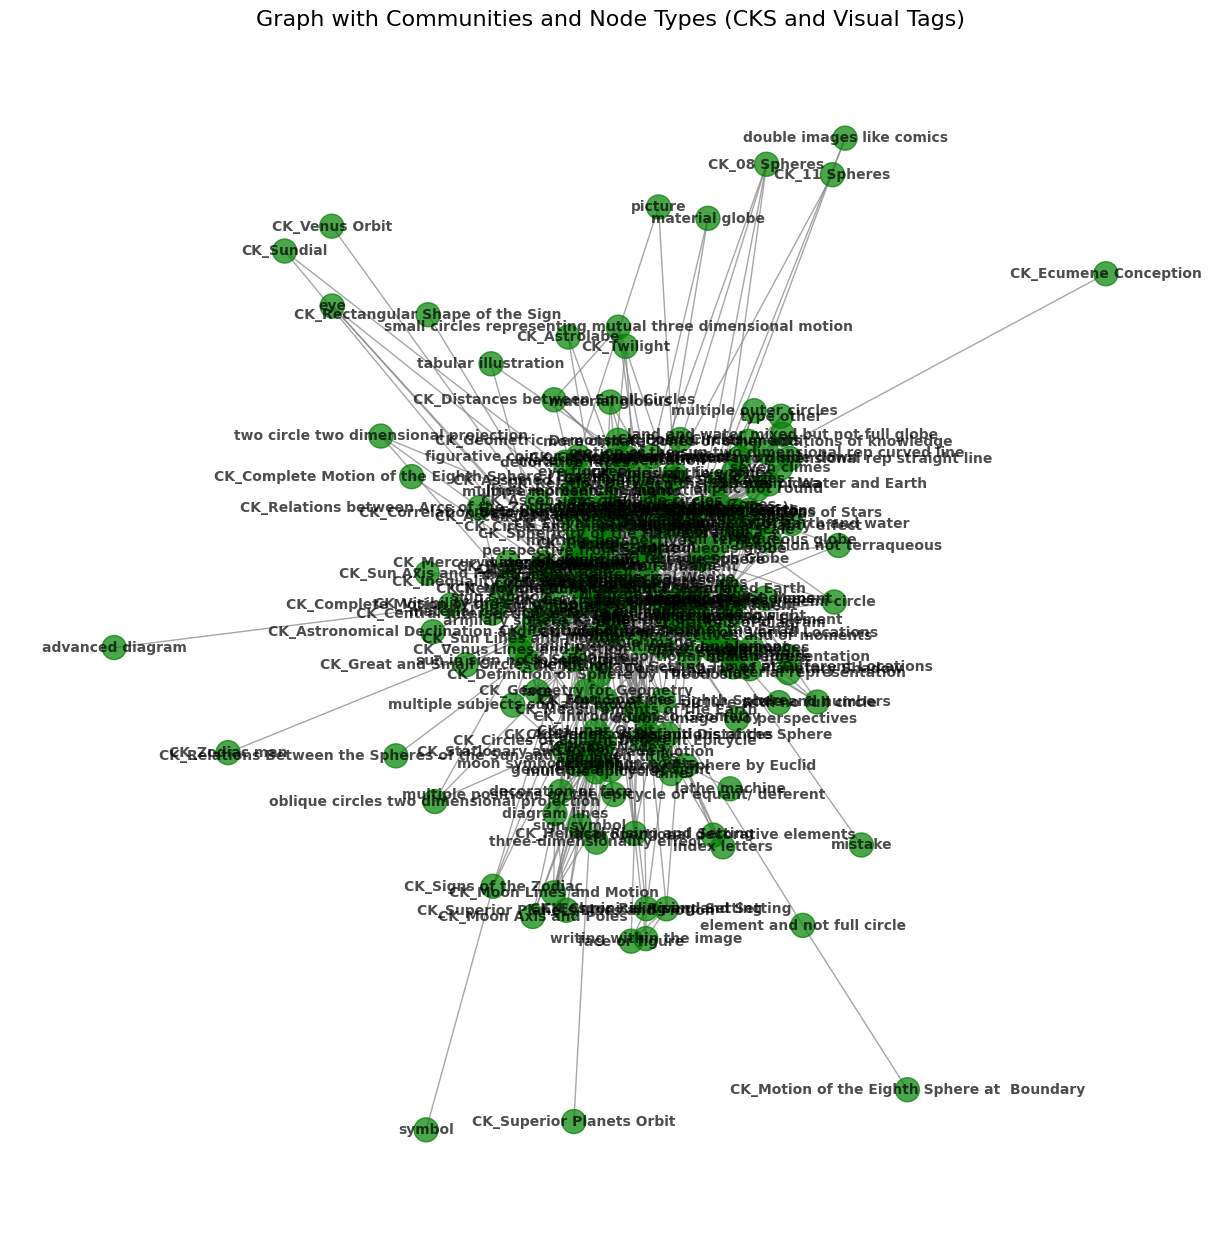

In [104]:
import networkx as nx
import community as community_louvain

# Create a graph from the network_df
G = nx.Graph()

# Add edges from network_df, using shared_image_count as the edge weight
for _, row in network_df.iterrows():
    G.add_edge(row['cks'], row['visual_tags'], weight=row['shared_image_count'])

# Apply Louvain method for community detection
partition = community_louvain.best_partition(G)

# Get the community for each node
communities = [partition[node] for node in G.nodes()]

# Generate positions for the graph layout
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Assign colors for the nodes based on their type ('cks' or 'visual_tags')
node_colors = ['blue' if 'cks' in node else 'green' for node in G.nodes()]

# Draw the graph with nodes colored by type (cks or visual_tags)
plt.figure(figsize=(12, 12))
nx.draw(G, pos, with_labels=True, node_size=300, font_size=10, font_weight='bold', node_color=node_colors, alpha=0.7, width=1.0, edge_color='gray')

# Show the plot
plt.title("Graph with Communities and Node Types (CKS and Visual Tags)", fontsize=16)
plt.show()


In [107]:
# Extract the unique visual_tags values from network_df
unique_visual_tags = network_df['visual_tags'].unique()

# Convert the unique visual_tags values to a DataFrame
unique_visual_tags_df = pd.DataFrame(unique_visual_tags, columns=['visual_tags'])

# Save the DataFrame to a CSV file
unique_visual_tags_df.to_csv('unique_visual_tags.csv', index=False)